In [1093]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1094]:
titanic = sns.load_dataset('titanic')

In [1095]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [1096]:
df = titanic.loc[:, 'survived':'age']

In [1097]:
df

,survived,pclass,sex,age
0,0,3,male,22.0
1,1,1,female,38.0
2,1,3,female,26.0
3,1,1,female,35.0
4,0,3,male,35.0
...,...,...,...,...
886,0,2,male,27.0
887,1,1,female,19.0
888,0,3,female,NaN
889,1,1,male,26.0


In [1098]:
columns = list(df.columns.values)

In [1099]:
columns

['survived', 'pclass', 'sex', 'age']

In [1100]:
columns_sorted = sorted(columns, reverse=False) # sorted 데이터 정렬

In [1101]:
columns_sorted

['age', 'pclass', 'sex', 'survived']

In [1102]:
df_sorted = df[columns_sorted]

In [1103]:
df_sorted

,age,pclass,sex,survived
0,22.0,3,male,0
1,38.0,1,female,1
2,26.0,3,female,1
3,35.0,1,female,1
4,35.0,3,male,0
...,...,...,...,...
886,27.0,2,male,0
887,19.0,1,female,1
888,NaN,3,female,0
889,26.0,1,male,1


In [1104]:
columns_reverse = sorted(columns, reverse=True) # sorted 데이터 정렬
df_reversed = df[columns_reverse]
df_reversed

,survived,sex,pclass,age
0,0,male,3,22.0
1,1,female,1,38.0
2,1,female,3,26.0
3,1,female,1,35.0
4,0,male,3,35.0
...,...,...,...,...
886,0,male,2,27.0
887,1,female,1,19.0
888,0,female,3,NaN
889,1,male,1,26.0


In [1105]:
col = ['age', 'survived']

In [1106]:
df_customed = df[col]
df_customed.head()

,age,survived
0,22.0,0
1,38.0,1
2,26.0,1
3,35.0,1
4,35.0,0


# GroupBy Mechanics

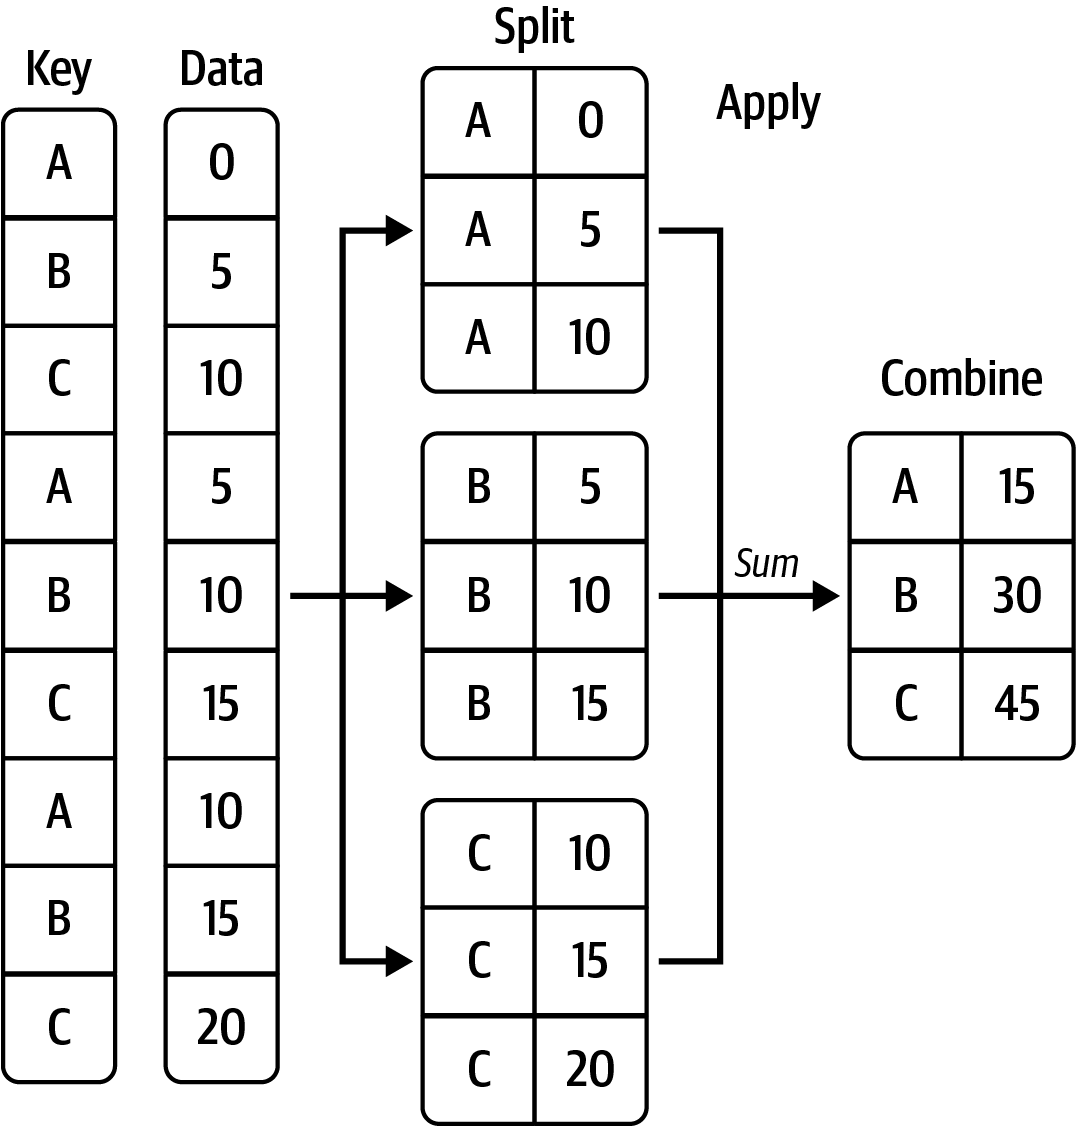

In [1107]:
df.head()

,survived,pclass,sex,age
0,0,3,male,22.0
1,1,1,female,38.0
2,1,3,female,26.0
3,1,1,female,35.0
4,0,3,male,35.0


In [1108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 28.0+ KB


In [1109]:
columns

['survived', 'pclass', 'sex', 'age']

In [1110]:
columns = ['age', 'sex', 'class', 'fare', 'survived']

In [1111]:
df = titanic.loc[:, columns]

In [1112]:
df.head()

,age,sex,class,fare,survived
0,22.0,male,Third,7.2500,0
1,38.0,female,First,71.2833,1
2,26.0,female,Third,7.9250,1
3,35.0,female,First,53.1000,1
4,35.0,male,Third,8.0500,0


In [1113]:
grouped = df.groupby(["class"], observed=True)

In [1114]:
grouped

In [1115]:
for i, j in grouped:
    print(i, len(j), type(j))
    print()
    print(j)
    print("="*50)
    print()

('First',) 216 <class 'pandas.core.frame.DataFrame'>

      age     sex  class     fare  survived
1    38.0  female  First  71.2833         1
3    35.0  female  First  53.1000         1
6    54.0    male  First  51.8625         0
11   58.0  female  First  26.5500         1
23   28.0    male  First  35.5000         1
..    ...     ...    ...      ...       ...
871  47.0  female  First  52.5542         1
872  33.0    male  First   5.0000         0
879  56.0  female  First  83.1583         1
887  19.0  female  First  30.0000         1
889  26.0    male  First  30.0000         1

[216 rows x 5 columns]

('Second',) 184 <class 'pandas.core.frame.DataFrame'>

      age     sex   class     fare  survived
9    14.0  female  Second  30.0708         1
15   55.0  female  Second  16.0000         1
17    NaN    male  Second  13.0000         1
20   35.0    male  Second  26.0000         0
21   34.0    male  Second  13.0000         1
..    ...     ...     ...      ...       ...
866  27.0  female  Seco

In [1116]:
j

,age,sex,class,fare,survived
0,22.0,male,Third,7.2500,0
2,26.0,female,Third,7.9250,1
4,35.0,male,Third,8.0500,0
5,NaN,male,Third,8.4583,0
7,2.0,male,Third,21.0750,0
...,...,...,...,...,...
882,22.0,female,Third,10.5167,0
884,25.0,male,Third,7.0500,0
885,39.0,female,Third,29.1250,0
888,NaN,female,Third,23.4500,0


In [1117]:
age_group = df.groupby(['age'])

In [1118]:
for i, j in age_group:
    print(i, len(j), type(j))
    print()
    print(j)
    print("="*50)
    print()

(0.42,) 1 <class 'pandas.core.frame.DataFrame'>

      age   sex  class    fare  survived
803  0.42  male  Third  8.5167         1

(0.67,) 1 <class 'pandas.core.frame.DataFrame'>

      age   sex   class  fare  survived
755  0.67  male  Second  14.5         1

(0.75,) 2 <class 'pandas.core.frame.DataFrame'>

      age     sex  class     fare  survived
469  0.75  female  Third  19.2583         1
644  0.75  female  Third  19.2583         1

(0.83,) 2 <class 'pandas.core.frame.DataFrame'>

      age   sex   class   fare  survived
78   0.83  male  Second  29.00         1
831  0.83  male  Second  18.75         1

(0.92,) 1 <class 'pandas.core.frame.DataFrame'>

      age   sex  class    fare  survived
305  0.92  male  First  151.55         1

(1.0,) 7 <class 'pandas.core.frame.DataFrame'>

     age     sex   class     fare  survived
164  1.0    male   Third  39.6875         0
172  1.0  female   Third  11.1333         1
183  1.0    male  Second  39.0000         1
381  1.0  female   Third  1

In [1119]:
average = grouped.mean(numeric_only=True)

In [1120]:
average

,age,fare,survived
class,,,
First,38.233441,84.154687,0.629630
Second,29.877630,20.662183,0.472826
Third,25.140620,13.675550,0.242363


In [1121]:
grouped_two = df.groupby(['class', 'sex'])

/tmp/ipykernel_2413/4142918645.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_two = df.groupby(['class', 'sex'])


In [1122]:
for key, group in grouped_two:
    print('key : ', key)
    print('size : ', len(group))
    print(group.head())
    print('='*50)
    print()

key :  ('First', 'female')
size :  94
     age     sex  class      fare  survived
1   38.0  female  First   71.2833         1
3   35.0  female  First   53.1000         1
11  58.0  female  First   26.5500         1
31   NaN  female  First  146.5208         1
52  49.0  female  First   76.7292         1

key :  ('First', 'male')
size :  122
     age   sex  class      fare  survived
6   54.0  male  First   51.8625         0
23  28.0  male  First   35.5000         1
27  19.0  male  First  263.0000         0
30  40.0  male  First   27.7208         0
34  28.0  male  First   82.1708         0

key :  ('Second', 'female')
size :  76
     age     sex   class     fare  survived
9   14.0  female  Second  30.0708         1
15  55.0  female  Second  16.0000         1
41  27.0  female  Second  21.0000         0
43   3.0  female  Second  41.5792         1
53  29.0  female  Second  26.0000         1

key :  ('Second', 'male')
size :  108
     age   sex   class  fare  survived
17   NaN  male  Second  13

In [1123]:
avg_two = grouped_two.mean(numeric_only=True)
avg_two

age        fare  survived
class  sex                                    
First  female  34.611765  106.125798  0.968085
       male    41.281386   67.226127  0.368852
Second female  28.722973   21.970121  0.921053
       male    30.740707   19.741782  0.157407
Third  female  21.750000   16.118810  0.500000
       male    26.507589   12.661633  0.135447

In [1124]:
grouped_class = df.groupby(['class']) # 리스트 쓰는걸 습관화 하자

/tmp/ipykernel_2413/266346033.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_class = df.groupby(['class']) # 리스트 쓰는걸 습관화 하자


In [1125]:
df.age

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [1126]:
age_df = df['age'].fillna(df['age'].mean())

In [1127]:
age_df.info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: age
Non-Null Count  Dtype  
--------------  -----  
891 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


In [1128]:
age_df.head()

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


In [1129]:
# bin : 구간이라고 생각하자
count, bin_dividers = np.histogram(age_df, bins=3)

In [1130]:
bin_dividers

array([ 0.42      , 26.94666667, 53.47333333, 80.        ])

In [1131]:
bin_names = ['A', 'B', 'C']

In [1132]:
# age_df['age_bin'] = pd.cut(x=age_df, bins=bin_dividers, labels=bin_names, include_lowest=True)

In [1133]:
# age_df

In [1134]:
df.head()

,age,sex,class,fare,survived
0,22.0,male,Third,7.2500,0
1,38.0,female,First,71.2833,1
2,26.0,female,Third,7.9250,1
3,35.0,female,First,53.1000,1
4,35.0,male,Third,8.0500,0


In [1135]:
df['age_bin'] = pd.cut(x=age_df, bins=bin_dividers, labels=bin_names, include_lowest=True)

In [1136]:
df

,age,sex,class,fare,survived,age_bin
0,22.0,male,Third,7.2500,0,A
1,38.0,female,First,71.2833,1,B
2,26.0,female,Third,7.9250,1,A
3,35.0,female,First,53.1000,1,B
4,35.0,male,Third,8.0500,0,B
...,...,...,...,...,...,...
886,27.0,male,Second,13.0000,0,B
887,19.0,female,First,30.0000,1,A
888,NaN,female,Third,23.4500,0,B
889,26.0,male,First,30.0000,1,A


In [1137]:
age_bin_g = df.groupby(['age_bin'])

/tmp/ipykernel_2413/739119603.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_bin_g = df.groupby(['age_bin'])


In [1138]:
for i, j in age_bin_g:
    print(i, len(j), type(j))
    print()
    print(j)
    print("="*50)
    print()

('A',) 319 <class 'pandas.core.frame.DataFrame'>

      age     sex   class     fare  survived age_bin
0    22.0    male   Third   7.2500         0       A
2    26.0  female   Third   7.9250         1       A
7     2.0    male   Third  21.0750         0       A
9    14.0  female  Second  30.0708         1       A
10    4.0  female   Third  16.7000         1       A
..    ...     ...     ...      ...       ...     ...
880  25.0  female  Second  26.0000         1       A
882  22.0  female   Third  10.5167         0       A
884  25.0    male   Third   7.0500         0       A
887  19.0  female   First  30.0000         1       A
889  26.0    male   First  30.0000         1       A

[319 rows x 6 columns]

('B',) 522 <class 'pandas.core.frame.DataFrame'>

      age     sex   class     fare  survived age_bin
1    38.0  female   First  71.2833         1       B
3    35.0  female   First  53.1000         1       B
4    35.0    male   Third   8.0500         0       B
5     NaN    male   Third  

In [1139]:
df[df['age'] < 10]

,age,sex,class,fare,survived,age_bin
7,2.00,male,Third,21.0750,0,A
10,4.00,female,Third,16.7000,1,A
16,2.00,male,Third,29.1250,0,A
24,8.00,female,Third,21.0750,0,A
43,3.00,female,Second,41.5792,1,A
...,...,...,...,...,...,...
827,1.00,male,Second,37.0042,1,A
831,0.83,male,Second,18.7500,1,A
850,4.00,male,Third,31.2750,0,A
852,9.00,female,Third,15.2458,0,A


In [1140]:
dummy = grouped_two.get_group(('Third', 'female'))

In [1141]:
dummy

,age,sex,class,fare,survived,age_bin
2,26.0,female,Third,7.9250,1,A
8,27.0,female,Third,11.1333,1,B
10,4.0,female,Third,16.7000,1,A
14,14.0,female,Third,7.8542,0,A
18,31.0,female,Third,18.0000,0,B
...,...,...,...,...,...,...
863,NaN,female,Third,69.5500,0,B
875,15.0,female,Third,7.2250,1,A
882,22.0,female,Third,10.5167,0,A
885,39.0,female,Third,29.1250,0,B


In [1142]:
for i, j in grouped:
    print(i, len(j), type(j))
    print()
    print(j)

('First',) 216 <class 'pandas.core.frame.DataFrame'>

      age     sex  class     fare  survived age_bin
1    38.0  female  First  71.2833         1       B
3    35.0  female  First  53.1000         1       B
6    54.0    male  First  51.8625         0       C
11   58.0  female  First  26.5500         1       C
23   28.0    male  First  35.5000         1       B
..    ...     ...    ...      ...       ...     ...
871  47.0  female  First  52.5542         1       B
872  33.0    male  First   5.0000         0       B
879  56.0  female  First  83.1583         1       C
887  19.0  female  First  30.0000         1       A
889  26.0    male  First  30.0000         1       A

[216 rows x 6 columns]
('Second',) 184 <class 'pandas.core.frame.DataFrame'>

      age     sex   class     fare  survived age_bin
9    14.0  female  Second  30.0708         1       A
15   55.0  female  Second  16.0000         1       C
17    NaN    male  Second  13.0000         1       B
20   35.0    male  Second  26.0

In [1143]:
std_all = grouped.std(numeric_only=True)

In [1144]:
std_all

,age,fare,survived
class,,,
First,14.802856,78.380373,0.484026
Second,14.001077,13.417399,0.500623
Third,12.495398,11.778142,0.428949


In [1145]:
df.groupby(['class'], observed=True)

In [1146]:
std_fare = grouped['fare'].std(numeric_only=True)

In [1147]:
std_fare

,fare
class,
First,78.380373
Second,13.417399
Third,11.778142


In [1148]:
# 'age', 'survived'
std_age_survived = grouped.std(numeric_only=True).drop(['fare'], axis=1)

In [1149]:
std_age_survived

,age,survived
class,,
First,14.802856,0.484026
Second,14.001077,0.500623
Third,12.495398,0.428949


In [1150]:
grouped[['class', 'sex']].value_counts()

class   sex   
First   male      122
        female     94
Second  male      108
        female     76
Third   male      347
        female    144
Name: count, dtype: int64

In [1151]:
grouped.agg('mean', numeric_only=True)

,age,fare,survived
class,,,
First,38.233441,84.154687,0.629630
Second,29.877630,20.662183,0.472826
Third,25.140620,13.675550,0.242363


In [1152]:
grouped.agg(['min', 'max'])

age           sex       fare           survived    
         min   max     min   max  min       max      min max
class                                                       
First   0.92  80.0  female  male  0.0  512.3292        0   1
Second  0.67  70.0  female  male  0.0   73.5000        0   1
Third   0.42  74.0  female  male  0.0   69.5500        0   1

In [1153]:
def min_max(x):
    return x.max() - x.min()

In [1154]:
grouped[['age', 'fare']].agg(min_max)

,age,fare
class,,
First,79.08,512.3292
Second,69.33,73.5000
Third,73.58,69.5500


In [1155]:
df['fare_cumsum'] = grouped['fare'].cumsum()

In [1156]:
df

,age,sex,class,fare,survived,age_bin,fare_cumsum
0,22.0,male,Third,7.2500,0,A,7.2500
1,38.0,female,First,71.2833,1,B,71.2833
2,26.0,female,Third,7.9250,1,A,15.1750
3,35.0,female,First,53.1000,1,B,124.3833
4,35.0,male,Third,8.0500,0,B,23.2250
...,...,...,...,...,...,...,...
886,27.0,male,Second,13.0000,0,B,3801.8417
887,19.0,female,First,30.0000,1,A,18147.4125
888,NaN,female,Third,23.4500,0,B,6706.9451
889,26.0,male,First,30.0000,1,A,18177.4125


In [1157]:
def z_score(x):
    return (x-x.mean()) / x.std()

In [1158]:
age_zscore = grouped['age'].transform(z_score)

In [1159]:
age_zscore

,age
0,-0.251342
1,-0.015770
2,0.068776
3,-0.218434
4,0.789041
...,...
886,-0.205529
887,-1.299306
888,NaN
889,-0.826424


In [1160]:
agg_zscore2 = grouped['age'].transform(lambda x : (x-x.mean())/x.std())

In [1161]:
agg_zscore2

,age
0,-0.251342
1,-0.015770
2,0.068776
3,-0.218434
4,0.789041
...,...
886,-0.205529
887,-1.299306
888,NaN
889,-0.826424


In [1162]:
(df['age'] - grouped['age'].transform('mean')) / grouped['age'].transform('std')

,age
0,-0.251342
1,-0.015770
2,0.068776
3,-0.218434
4,0.789041
...,...
886,-0.205529
887,-1.299306
888,NaN
889,-0.826424


In [1163]:
grouped[['age', 'survived']].apply(z_score)

age  survived
class                        
First 1   -0.015770  0.765188
      3   -0.218434  0.765188
      6    1.065103 -1.300819
      11   1.335321  0.765188
      23  -0.691315  0.765188
...             ...       ...
Third 882 -0.251342 -0.565014
      884 -0.011254 -0.565014
      885  1.109159 -0.565014
      888       NaN -0.565014
      890  0.548953 -0.565014

[891 rows x 2 columns]

In [1164]:
grouped.filter(lambda x: len(x) >= 200)

,age,sex,class,fare,survived,age_bin,fare_cumsum
0,22.0,male,Third,7.2500,0,A,7.2500
1,38.0,female,First,71.2833,1,B,71.2833
2,26.0,female,Third,7.9250,1,A,15.1750
3,35.0,female,First,53.1000,1,B,124.3833
4,35.0,male,Third,8.0500,0,B,23.2250
...,...,...,...,...,...,...,...
885,39.0,female,Third,29.1250,0,B,6683.4951
887,19.0,female,First,30.0000,1,A,18147.4125
888,NaN,female,Third,23.4500,0,B,6706.9451
889,26.0,male,First,30.0000,1,A,18177.4125


In [1165]:
grouped[['age', 'survived']].apply(lambda x: x.describe())

age    survived
class                               
First  count  186.000000  216.000000
       mean    38.233441    0.629630
       std     14.802856    0.484026
       min      0.920000    0.000000
       25%     27.000000    0.000000
       50%     37.000000    1.000000
       75%     49.000000    1.000000
       max     80.000000    1.000000
Second count  173.000000  184.000000
       mean    29.877630    0.472826
       std     14.001077    0.500623
       min      0.670000    0.000000
       25%     23.000000    0.000000
       50%     29.000000    0.000000
       75%     36.000000    1.000000
       max     70.000000    1.000000
Third  count  355.000000  491.000000
       mean    25.140620    0.242363
       std     12.495398    0.428949
       min      0.420000    0.000000
       25%     18.000000    0.000000
       50%     24.000000    0.000000
       75%     32.000000    0.000000
       max     74.000000    1.000000

In [1166]:
age_filter = grouped[['age', 'survived']].apply(lambda x: x['age'].mean() < 30)

In [1167]:
age_filter

,0
class,
First,False
Second,True
Third,True


In [1168]:
df.loc[df['class'].isin(age_filter[age_filter==True].index), ['age', 'survived']]

,age,survived
0,22.0,0
2,26.0,1
4,35.0,0
5,NaN,0
7,2.0,0
...,...,...
884,25.0,0
885,39.0,0
886,27.0,0
888,NaN,0


In [1169]:
from datetime import datetime, timedelta

In [1170]:
dt = datetime.now()

In [1171]:
dt

datetime.datetime(2026, 4, 9, 7, 43, 1, 703813)

In [1172]:
dt.day

9

In [1173]:
dt.month

4

In [1174]:
type(dt)

datetime.datetime

In [1175]:
dt.minute

43

In [1176]:
dt.microsecond

703813

In [1177]:
dt_man = datetime(2026, 4, 9)

In [1178]:
dt_man

datetime.datetime(2026, 4, 9, 0, 0)

In [1179]:
dt.time()

datetime.time(7, 43, 1, 703813)

In [1180]:
dt_man.time()

datetime.time(0, 0)

In [1181]:
dt

datetime.datetime(2026, 4, 9, 7, 43, 1, 703813)

In [1182]:
dt.strftime('%m/%d/%Y %H:%M')

'04/09/2026 07:43'

In [1183]:
type(dt.strftime('%m/%d/%Y %H:%M'))

str

In [1184]:
dt.strptime('20260409', '%Y%m%d')

datetime.datetime(2026, 4, 9, 0, 0)

In [1185]:
type(dt.strptime('20260409', '%Y%m%d'))

datetime.datetime

In [1186]:
dt

datetime.datetime(2026, 4, 9, 7, 43, 1, 703813)

In [1187]:
dt.replace(minute=0, second=0)

datetime.datetime(2026, 4, 9, 7, 0, 0, 703813)

In [1188]:
delta = datetime.now() - dt

In [1189]:
delta

datetime.timedelta(microseconds=65548)

In [1190]:
base_time = datetime.now().replace(minute = 0, second = 0, microsecond = 0)

In [1191]:
base_time

datetime.datetime(2026, 4, 9, 7, 0)

In [1192]:
future_time = datetime(2026, 4, 9)

In [1193]:
future_time = base_time

In [1194]:
base_time + timedelta(days=365)

datetime.datetime(2027, 4, 9, 7, 0)

In [1195]:
base_time - timedelta(days=365)

datetime.datetime(2025, 4, 9, 7, 0)

In [1196]:
base_time - datetime(1999, 11, 15)

datetime.timedelta(days=9642, seconds=25200)

In [1197]:
ls ./drive/MyDrive/data/stock*

./drive/MyDrive/data/stock-data.csv


In [1198]:
df = pd.read_csv('./drive/MyDrive/data/stock-data.csv')

In [1199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    20 non-null     object
 1   Close   20 non-null     int64 
 2   Start   20 non-null     int64 
 3   High    20 non-null     int64 
 4   Low     20 non-null     int64 
 5   Volume  20 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 1.1+ KB


In [1200]:
df.head()

,Date,Close,Start,High,Low,Volume
0,2018-07-02,10100,10850,10900,10000,137977
1,2018-06-29,10700,10550,10900,9990,170253
2,2018-06-28,10400,10900,10950,10150,155769
3,2018-06-27,10900,10800,11050,10500,133548
4,2018-06-26,10800,10900,11000,10700,63039


In [1201]:
df['new_Date'] = pd.to_datetime(df['Date'])

In [1202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      20 non-null     object        
 1   Close     20 non-null     int64         
 2   Start     20 non-null     int64         
 3   High      20 non-null     int64         
 4   Low       20 non-null     int64         
 5   Volume    20 non-null     int64         
 6   new_Date  20 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 1.2+ KB


In [1203]:
df.Date.values

array(['2018-07-02', '2018-06-29', '2018-06-28', '2018-06-27',
       '2018-06-26', '2018-06-25', '2018-06-22', '2018-06-21',
       '2018-06-20', '2018-06-19', '2018-06-18', '2018-06-15',
       '2018-06-14', '2018-06-12', '2018-06-11', '2018-06-08',
       '2018-06-07', '2018-06-05', '2018-06-04', '2018-06-01'],
      dtype=object)

In [1204]:
ts_dates = pd.to_datetime(df.Date.values)

In [1205]:
ts_dates # 타임스태프

DatetimeIndex(['2018-07-02', '2018-06-29', '2018-06-28', '2018-06-27',
               '2018-06-26', '2018-06-25', '2018-06-22', '2018-06-21',
               '2018-06-20', '2018-06-19', '2018-06-18', '2018-06-15',
               '2018-06-14', '2018-06-12', '2018-06-11', '2018-06-08',
               '2018-06-07', '2018-06-05', '2018-06-04', '2018-06-01'],
              dtype='datetime64[ns]', freq=None)

In [1206]:
pr_day = ts_dates.to_period(freq='D') # freq는 기간을 의미

In [1207]:
pr_day

PeriodIndex(['2018-07-02', '2018-06-29', '2018-06-28', '2018-06-27',
             '2018-06-26', '2018-06-25', '2018-06-22', '2018-06-21',
             '2018-06-20', '2018-06-19', '2018-06-18', '2018-06-15',
             '2018-06-14', '2018-06-12', '2018-06-11', '2018-06-08',
             '2018-06-07', '2018-06-05', '2018-06-04', '2018-06-01'],
            dtype='period[D]')

In [1208]:
df2 = df.set_index('new_Date')

In [1209]:
df2

,Date,Close,Start,High,Low,Volume
new_Date,,,,,,
2018-07-02,2018-07-02,10100,10850,10900,10000,137977
2018-06-29,2018-06-29,10700,10550,10900,9990,170253
2018-06-28,2018-06-28,10400,10900,10950,10150,155769
2018-06-27,2018-06-27,10900,10800,11050,10500,133548
2018-06-26,2018-06-26,10800,10900,11000,10700,63039
2018-06-25,2018-06-25,11150,11400,11450,11000,55519
2018-06-22,2018-06-22,11300,11250,11450,10750,134805
2018-06-21,2018-06-21,11200,11350,11750,11200,133002
2018-06-20,2018-06-20,11550,11200,11600,10900,308596


In [1210]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 20 entries, 2018-07-02 to 2018-06-01
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    20 non-null     object
 1   Close   20 non-null     int64 
 2   Start   20 non-null     int64 
 3   High    20 non-null     int64 
 4   Low     20 non-null     int64 
 5   Volume  20 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 1.1+ KB


In [1211]:
ts_ms = pd.date_range(start='2026-01-01', end=None, periods=6, freq='10D', tz='Asia/Seoul')

In [1212]:
ts_ms # freq=MS 월의 시작을 의미 freq=D 일 수 10D 하면 10일 후의 날짜를 보여줌

DatetimeIndex(['2026-01-01 00:00:00+09:00', '2026-01-11 00:00:00+09:00',
               '2026-01-21 00:00:00+09:00', '2026-01-31 00:00:00+09:00',
               '2026-02-10 00:00:00+09:00', '2026-02-20 00:00:00+09:00'],
              dtype='datetime64[ns, Asia/Seoul]', freq='10D')

https://pandas.pydata.org/docs/user_guide/timeseries.html

In [1213]:
df['Year'] = df['new_Date'].dt.year
df['Month'] = df['new_Date'].dt.month
df['Day'] = df['new_Date'].dt.day

In [1214]:
df['Date_m'] = df['new_Date'].dt.to_period(freq='M')

In [1215]:
df.head()

,Date,Close,Start,High,Low,Volume,new_Date,Year,Month,Day,Date_m
0,2018-07-02,10100,10850,10900,10000,137977,2018-07-02,2018,7,2,2018-07
1,2018-06-29,10700,10550,10900,9990,170253,2018-06-29,2018,6,29,2018-06
2,2018-06-28,10400,10900,10950,10150,155769,2018-06-28,2018,6,28,2018-06
3,2018-06-27,10900,10800,11050,10500,133548,2018-06-27,2018,6,27,2018-06
4,2018-06-26,10800,10900,11000,10700,63039,2018-06-26,2018,6,26,2018-06


In [1216]:
df.set_index('new_Date', inplace=True)

In [1217]:
df3 = df.sort_index()

In [1218]:
df3

,Date,Close,Start,High,Low,Volume,Year,Month,Day,Date_m
new_Date,,,,,,,,,,
2018-06-01,2018-06-01,11900,11800,12100,11750,32062,2018,6,1,2018-06
2018-06-04,2018-06-04,11900,11900,12200,11700,25171,2018,6,4,2018-06
2018-06-05,2018-06-05,12150,11800,12250,11800,42485,2018,6,5,2018-06
2018-06-07,2018-06-07,11950,12200,12300,11900,49088,2018,6,7,2018-06
2018-06-08,2018-06-08,11950,11950,12200,11800,59258,2018,6,8,2018-06
2018-06-11,2018-06-11,11950,12000,12250,11950,62293,2018,6,11,2018-06
2018-06-12,2018-06-12,13200,12200,13300,12050,558148,2018,6,12,2018-06
2018-06-14,2018-06-14,13450,13200,13700,13150,347451,2018,6,14,2018-06
2018-06-15,2018-06-15,13400,13600,13600,12900,201376,2018,6,15,2018-06


In [1219]:
df3.loc['2018-06-27':'2018-07-02']

,Date,Close,Start,High,Low,Volume,Year,Month,Day,Date_m
new_Date,,,,,,,,,,
2018-06-27,2018-06-27,10900,10800,11050,10500,133548,2018,6,27,2018-06
2018-06-28,2018-06-28,10400,10900,10950,10150,155769,2018,6,28,2018-06
2018-06-29,2018-06-29,10700,10550,10900,9990,170253,2018,6,29,2018-06
2018-07-02,2018-07-02,10100,10850,10900,10000,137977,2018,7,2,2018-07


In [1220]:
df[df.index < '2018-06-07']

,Date,Close,Start,High,Low,Volume,Year,Month,Day,Date_m
new_Date,,,,,,,,,,
2018-06-05,2018-06-05,12150,11800,12250,11800,42485,2018,6,5,2018-06
2018-06-04,2018-06-04,11900,11900,12200,11700,25171,2018,6,4,2018-06
2018-06-01,2018-06-01,11900,11800,12100,11750,32062,2018,6,1,2018-06


In [1221]:
df3.index + pd.Timedelta(days=100)

DatetimeIndex(['2018-09-09', '2018-09-12', '2018-09-13', '2018-09-15',
               '2018-09-16', '2018-09-19', '2018-09-20', '2018-09-22',
               '2018-09-23', '2018-09-26', '2018-09-27', '2018-09-28',
               '2018-09-29', '2018-09-30', '2018-10-03', '2018-10-04',
               '2018-10-05', '2018-10-06', '2018-10-07', '2018-10-10'],
              dtype='datetime64[ns]', name='new_Date', freq=None)

In [1222]:
df3.head()

,Date,Close,Start,High,Low,Volume,Year,Month,Day,Date_m
new_Date,,,,,,,,,,
2018-06-01,2018-06-01,11900,11800,12100,11750,32062,2018,6,1,2018-06
2018-06-04,2018-06-04,11900,11900,12200,11700,25171,2018,6,4,2018-06
2018-06-05,2018-06-05,12150,11800,12250,11800,42485,2018,6,5,2018-06
2018-06-07,2018-06-07,11950,12200,12300,11900,49088,2018,6,7,2018-06
2018-06-08,2018-06-08,11950,11950,12200,11800,59258,2018,6,8,2018-06


In [1223]:
ts = df3['Close']

In [1224]:
ts

,Close
new_Date,
2018-06-01,11900
2018-06-04,11900
2018-06-05,12150
2018-06-07,11950
2018-06-08,11950
2018-06-11,11950
2018-06-12,13200
2018-06-14,13450
2018-06-15,13400


In [1225]:
(ts/ts.shift(1) - 1) * 100

,Close
new_Date,
2018-06-01,NaN
2018-06-04,0.000000
2018-06-05,2.100840
2018-06-07,-1.646091
2018-06-08,0.000000
2018-06-11,0.000000
2018-06-12,10.460251
2018-06-14,1.893939
2018-06-15,-0.371747


In [1226]:
rng = pd.date_range('2026-01-01', periods=120, freq='D')

In [1227]:
rng

DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
               '2026-01-09', '2026-01-10',
               ...
               '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24',
               '2026-04-25', '2026-04-26', '2026-04-27', '2026-04-28',
               '2026-04-29', '2026-04-30'],
              dtype='datetime64[ns]', length=120, freq='D')

In [1228]:
ts = pd.Series(np.random.randn(len(rng)), rng)

In [1229]:
ts.resample('M', kind='period').mean()

/tmp/ipykernel_2413/1597458493.py:1: FutureWarning: The 'kind' keyword in Series.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  ts.resample('M', kind='period').mean()
/tmp/ipykernel_2413/1597458493.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts.resample('M', kind='period').mean()


,0
2026-01,-0.150748
2026-02,0.143895
2026-03,0.027672
2026-04,0.329275


In [1230]:
rng = pd.date_range('2026-04-09', periods=6, freq='min')

In [1231]:
rng

DatetimeIndex(['2026-04-09 00:00:00', '2026-04-09 00:01:00',
               '2026-04-09 00:02:00', '2026-04-09 00:03:00',
               '2026-04-09 00:04:00', '2026-04-09 00:05:00'],
              dtype='datetime64[ns]', freq='min')

In [1232]:
ts = pd.Series(np.arange(6), index=rng)

In [1233]:
ts

,0
2026-04-09 00:00:00,0
2026-04-09 00:01:00,1
2026-04-09 00:02:00,2
2026-04-09 00:03:00,3
2026-04-09 00:04:00,4
2026-04-09 00:05:00,5


In [1234]:
ts.resample('2min').sum()

,0
2026-04-09 00:00:00,1
2026-04-09 00:02:00,5
2026-04-09 00:04:00,9


9시 00 분부터 해서 9시 59분까지 분마다 기온관측 --> 60개 평균 --> 이건 9시 기온

00:00 ~ 00:59 -> 이건 몇시의 온도지? 4월 5일 24시 기온인지 4월 6일 00시 기온인지 --> 4월 6일 00시 기온

In [1235]:
ts.resample('2min', closed='right').sum()

,0
2026-04-08 23:58:00,0
2026-04-09 00:00:00,3
2026-04-09 00:02:00,7
2026-04-09 00:04:00,5


In [1236]:
ts.resample('2min', closed='left').sum()

,0
2026-04-09 00:00:00,1
2026-04-09 00:02:00,5
2026-04-09 00:04:00,9


In [1237]:
ts.resample('2min', closed='right', label='right').sum()

,0
2026-04-09 00:00:00,0
2026-04-09 00:02:00,3
2026-04-09 00:04:00,7
2026-04-09 00:06:00,5


In [1238]:
rng = pd.date_range('2026-01-01', periods=1440, freq='min')

In [1239]:
rng

DatetimeIndex(['2026-01-01 00:00:00', '2026-01-01 00:01:00',
               '2026-01-01 00:02:00', '2026-01-01 00:03:00',
               '2026-01-01 00:04:00', '2026-01-01 00:05:00',
               '2026-01-01 00:06:00', '2026-01-01 00:07:00',
               '2026-01-01 00:08:00', '2026-01-01 00:09:00',
               ...
               '2026-01-01 23:50:00', '2026-01-01 23:51:00',
               '2026-01-01 23:52:00', '2026-01-01 23:53:00',
               '2026-01-01 23:54:00', '2026-01-01 23:55:00',
               '2026-01-01 23:56:00', '2026-01-01 23:57:00',
               '2026-01-01 23:58:00', '2026-01-01 23:59:00'],
              dtype='datetime64[ns]', length=1440, freq='min')

In [1240]:
ts = pd.Series(np.arange(1, len(rng) + 1), index=rng)

In [1241]:
ts

,0
2026-01-01 00:00:00,1
2026-01-01 00:01:00,2
2026-01-01 00:02:00,3
2026-01-01 00:03:00,4
2026-01-01 00:04:00,5
...,...
2026-01-01 23:55:00,1436
2026-01-01 23:56:00,1437
2026-01-01 23:57:00,1438
2026-01-01 23:58:00,1439


In [1242]:
ts.resample('60min').mean()

,0
2026-01-01 00:00:00,30.5
2026-01-01 01:00:00,90.5
2026-01-01 02:00:00,150.5
2026-01-01 03:00:00,210.5
2026-01-01 04:00:00,270.5
2026-01-01 05:00:00,330.5
2026-01-01 06:00:00,390.5
2026-01-01 07:00:00,450.5
2026-01-01 08:00:00,510.5
2026-01-01 09:00:00,570.5


In [1243]:
ts.resample('3H').agg(['mean', 'size'])

/tmp/ipykernel_2413/3227082012.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts.resample('3H').agg(['mean', 'size'])


,mean,size
2026-01-01 00:00:00,90.5,180
2026-01-01 03:00:00,270.5,180
2026-01-01 06:00:00,450.5,180
2026-01-01 09:00:00,630.5,180
2026-01-01 12:00:00,810.5,180
2026-01-01 15:00:00,990.5,180
2026-01-01 18:00:00,1170.5,180
2026-01-01 21:00:00,1350.5,180


In [1244]:
frame = pd.DataFrame(np.random.randn(8, 4), index=pd.date_range('1-2026', '3-2026', freq='W-WED'), columns=['daum', 'naver', 'nate', 'zum'])

In [1245]:
frame

,daum,naver,nate,zum
2026-01-07,0.081718,0.277621,1.150608,-0.163610
2026-01-14,1.129918,0.834758,-0.447479,0.778707
2026-01-21,0.399806,-1.430232,-0.031963,-0.997382
2026-01-28,-0.445272,-0.483632,-0.727319,0.544146
2026-02-04,1.233900,0.038824,1.819191,0.509330
2026-02-11,-1.757988,-1.422593,0.529303,-1.055992
2026-02-18,0.049827,1.073999,1.219917,-0.598480
2026-02-25,-1.225561,-0.108529,-1.150093,0.274208


In [1246]:
df_daily = frame.resample('D').asfreq()

In [1247]:
df_daily

,daum,naver,nate,zum
2026-01-07,0.081718,0.277621,1.150608,-0.163610
2026-01-08,NaN,NaN,NaN,NaN
2026-01-09,NaN,NaN,NaN,NaN
2026-01-10,NaN,NaN,NaN,NaN
2026-01-11,NaN,NaN,NaN,NaN
2026-01-12,NaN,NaN,NaN,NaN
2026-01-13,NaN,NaN,NaN,NaN
2026-01-14,1.129918,0.834758,-0.447479,0.778707
2026-01-15,NaN,NaN,NaN,NaN
2026-01-16,NaN,NaN,NaN,NaN


In [1249]:
frame.resample('D').ffill(limit=2)

,daum,naver,nate,zum
2026-01-07,0.081718,0.277621,1.150608,-0.163610
2026-01-08,0.081718,0.277621,1.150608,-0.163610
2026-01-09,0.081718,0.277621,1.150608,-0.163610
2026-01-10,NaN,NaN,NaN,NaN
2026-01-11,NaN,NaN,NaN,NaN
2026-01-12,NaN,NaN,NaN,NaN
2026-01-13,NaN,NaN,NaN,NaN
2026-01-14,1.129918,0.834758,-0.447479,0.778707
2026-01-15,1.129918,0.834758,-0.447479,0.778707
2026-01-16,1.129918,0.834758,-0.447479,0.778707


In [1251]:
ls ./drive/MyDrive/data/stock_px_2.csv

./drive/MyDrive/data/stock_px_2.csv


In [1253]:
close_all = pd.read_csv('./drive/MyDrive/data/stock_px_2.csv', parse_dates=True, index_col=[0])

In [1258]:
close_all.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2214 entries, 2003-01-02 to 2011-10-14
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2214 non-null   float64
 1   MSFT    2214 non-null   float64
 2   XOM     2214 non-null   float64
 3   SPX     2214 non-null   float64
dtypes: float64(4)
memory usage: 86.5 KB


In [1255]:
close_all.head()

,AAPL,MSFT,XOM,SPX
2003-01-02,7.40,21.11,29.22,909.03
2003-01-03,7.45,21.14,29.24,908.59
2003-01-06,7.45,21.52,29.96,929.01
2003-01-07,7.43,21.93,28.95,922.93
2003-01-08,7.28,21.31,28.83,909.93


In [1256]:
close_px = close_all.resample('B').ffill()

In [1259]:
close_px.head()

,AAPL,MSFT,XOM,SPX
2003-01-02,7.40,21.11,29.22,909.03
2003-01-03,7.45,21.14,29.24,908.59
2003-01-06,7.45,21.52,29.96,929.01
2003-01-07,7.43,21.93,28.95,922.93
2003-01-08,7.28,21.31,28.83,909.93


In [1260]:
close_px = close_px[['AAPL', 'MSFT', 'XOM']]

In [1261]:
close_px

,AAPL,MSFT,XOM
2003-01-02,7.40,21.11,29.22
2003-01-03,7.45,21.14,29.24
2003-01-06,7.45,21.52,29.96
2003-01-07,7.43,21.93,28.95
2003-01-08,7.28,21.31,28.83
...,...,...,...
2011-10-10,388.81,26.94,76.28
2011-10-11,400.29,27.00,76.27
2011-10-12,402.19,26.96,77.16
2011-10-13,408.43,27.18,76.37


<Axes: >

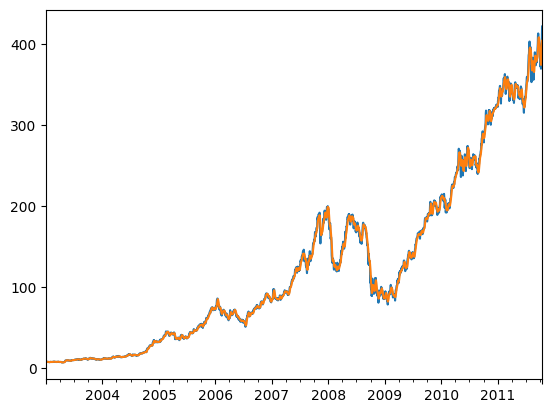

In [1266]:
close_px.AAPL.plot()
close_px.AAPL.rolling(5).mean().plot()

<Axes: >

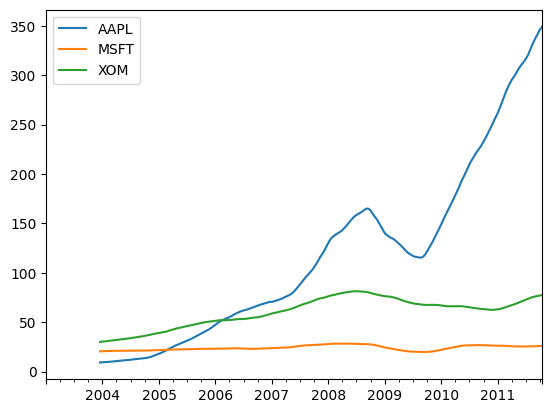

In [1269]:
close_px[['AAPL', 'MSFT', 'XOM']].rolling(250).mean().plot() # 투자분석때 배운 이동평균선 이렇게 활용하자

In [1273]:
df = close_px.AAPL.rolling(10, min_periods=4).mean()

In [1274]:
df.head()

,AAPL
2003-01-02,NaN
2003-01-03,NaN
2003-01-06,NaN
2003-01-07,7.4325
2003-01-08,7.4020


In [1275]:
close_px.AAPL.rolling(10, min_periods=4).sum() # 이동 합계

,AAPL
2003-01-02,NaN
2003-01-03,NaN
2003-01-06,NaN
2003-01-07,29.73
2003-01-08,37.01
...,...
2011-10-10,3829.49
2011-10-11,3830.52
2011-10-12,3835.70
2011-10-13,3853.56
